# DeepHalo Featureless Model - Example Usage

This notebook demonstrates how to use the **DeepHaloFeatureless** custom model that has been added to the choice-learn library.

The DeepHalo Featureless model is a deep neural network for discrete choice modeling that operates purely on item availability masks without requiring item or customer features. It uses residual blocks (Quadratic and Exponential) to learn complex choice patterns.

## Overview
- Load synthetic choice data
- Create ChoiceDataset
- Train DeepHaloFeatureless model
- Evaluate and visualize results

## 1. Import Required Libraries

In [2]:
import sys
import os

# Add choice-learn to path
sys.path.insert(0, '/home/yrsun/project/q3-discrete-choice-model/choice-learn')

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from choice_learn.data import ChoiceDataset
from choice_learn.models import DeepHaloFeatureless

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.2.6
Pandas version: 2.3.3


## 2. Load Synthetic Choice Data

We'll use the synthetic dataset that was generated with:
- 20 products in the universe
- Choice sets of fixed size 15
- 1,240,320 training samples
- 310,080 test samples

In [3]:
# Load data
data_dir = '/home/yrsun/project/q3-discrete-choice-model/data'
df_train = pd.read_csv(f'{data_dir}/Synthetic_20-15-80_Train.csv')
df_test = pd.read_csv(f'{data_dir}/Synthetic_20-15-20_Test.csv')

print(f"Train dataset shape: {df_train.shape}")
print(f"Test dataset shape: {df_test.shape}")
print(f"\nFirst few rows:")
df_train.head(3)

Train dataset shape: (1240320, 40)
Test dataset shape: (310080, 40)

First few rows:


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Prepare Data for ChoiceDataset

Extract features:
- **X columns**: Availability mask (which items are in the choice set)
- **Y columns**: Actual choice (one-hot encoded)

In [4]:
n_products = 20

# Extract availability masks (X columns)
X_train = df_train[[f'X{i}' for i in range(n_products)]].values
X_test = df_test[[f'X{i}' for i in range(n_products)]].values

# Extract choices (Y columns) and convert to indices
Y_train = df_train[[f'Y{i}' for i in range(n_products)]].values
Y_test = df_test[[f'Y{i}' for i in range(n_products)]].values

y_train = np.argmax(Y_train, axis=1)
y_test = np.argmax(Y_test, axis=1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nExample:")
print(f"  Availability mask: {X_train[0]}")
print(f"  Number of available items: {X_train[0].sum()}")
print(f"  Chosen item index: {y_train[0]}")

X_train shape: (1240320, 20)
y_train shape: (1240320,)

Example:
  Availability mask: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
  Number of available items: 15.0
  Chosen item index: 5


## 4. Create ChoiceDataset Objects

For the featureless model, we use the availability mask as the only input feature.

In [8]:
# Use a subset of the data for faster training in this example
# Remove these lines to use full dataset
n_train = min(50000, len(X_train))
n_test = min(10000, len(X_test))

X_train_subset = X_train[:n_train]
y_train_subset = y_train[:n_train]
X_test_subset = X_test[:n_test]
y_test_subset = y_test[:n_test]

print(f"Using {n_train} training samples and {n_test} test samples")

# Reshape availability to add feature dimension: (batch, items) -> (batch, items, 1)
X_train_reshaped = X_train_subset[:, :, np.newaxis]
X_test_reshaped = X_test_subset[:, :, np.newaxis]

print(f"Reshaped X_train: {X_train_reshaped.shape}")
print(f"Reshaped X_test: {X_test_reshaped.shape}")

# Create ChoiceDataset
dataset_train = ChoiceDataset(
    items_features_by_choice=X_train_reshaped,
    available_items_by_choice=X_train_subset.astype(int),
    choices=y_train_subset,
    shared_features_by_choice=(),
    items_features_by_choice_names=["availability"],
)

dataset_test = ChoiceDataset(
    items_features_by_choice=X_test_reshaped,
    available_items_by_choice=X_test_subset.astype(int),
    choices=y_test_subset,
    shared_features_by_choice=(),
    items_features_by_choice_names=["availability"],
)

print(f"\nTrain ChoiceDataset: {len(dataset_train)} choices")
print(f"Test ChoiceDataset: {len(dataset_test)} choices")
print(f"Number of items: {dataset_train.get_n_items()}")

                                    fit models needing them such as Conditional Logit.
                                    fit models needing them such as Conditional Logit.


Using 50000 training samples and 10000 test samples
Reshaped X_train: (50000, 20, 1)
Reshaped X_test: (10000, 20, 1)

Train ChoiceDataset: 50000 choices
Test ChoiceDataset: 10000 choices
Number of items: 20


## 5. Initialize DeepHaloFeatureless Model

Configure the model architecture:
- **opt_size**: Number of items (20)
- **depth**: Number of layers (5 = 1 input + 4 residual blocks + 1 output)
- **resnet_width**: Hidden dimension (64)
- **block_types**: Type of each residual block ('qua' for quadratic, 'exa' for exponential)

In [12]:
model = DeepHaloFeatureless(
    opt_size=n_products,
    depth=5,  # 4 residual blocks
    resnet_width=348,
    block_types=['qua']*(5-1),  # All quadratic blocks
    optimizer='Adam',
    lr=0.0001,
    epochs=500,
    batch_size=1024,
)

print(f"Model initialized successfully!")
print(f"Number of trainable weight groups: {len(model.trainable_weights)}")
print(f"\nModel configuration:")
print(f"  - Input size: {model.opt_size}")
print(f"  - Depth: {model.depth}")
print(f"  - Hidden width: {model.resnet_width}")
print(f"  - Block types: {model.block_types}")

Model initialized successfully!
Number of trainable weight groups: 6

Model configuration:
  - Input size: 20
  - Depth: 5
  - Hidden width: 348
  - Block types: ['qua', 'qua', 'qua', 'qua']


## 6. Train the Model

In [13]:
print("Training the model...")
history = model.fit(dataset_train)

print("\nTraining completed!")
print(f"Final training loss: {history['train_loss'][-1]:.4f}")

Training the model...


Epoch 499 Train Loss 2.2563: 100%|██████████| 500/500 [03:49<00:00,  2.17it/s]


Training completed!
Final training loss: 2.2563


## 7. Visualize Training Progress

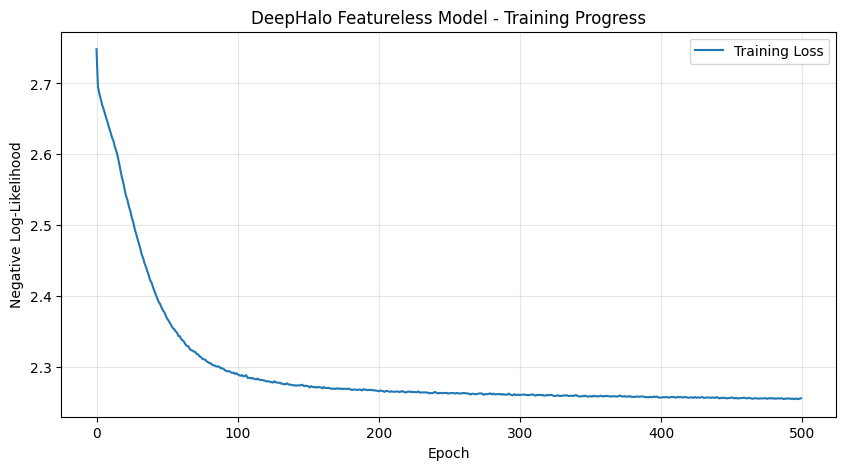

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('DeepHalo Featureless Model - Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Evaluate on Test Set

In [16]:
test_nll = model.evaluate(dataset_test)
print(f"Test Negative Log-Likelihood: {test_nll:.4f}")

# Calculate accuracy
predictions = model.predict_probas(dataset_test)
predicted_choices = np.argmax(predictions, axis=1)
accuracy = (predicted_choices == y_test_subset).mean()
print(f"Test Accuracy: {accuracy:.4f}")

# Calculate top-3 accuracy
top3_predictions = np.argsort(predictions, axis=1)[:, -3:]
top3_accuracy = np.mean([y_test_subset[i] in top3_predictions[i] for i in range(len(y_test_subset))])
print(f"Top-3 Accuracy: {top3_accuracy:.4f}")

Test Negative Log-Likelihood: 2.4134
Test Accuracy: 0.2083
Top-3 Accuracy: 0.4756


## 9. Visualize Predictions

Let's look at some example predictions:

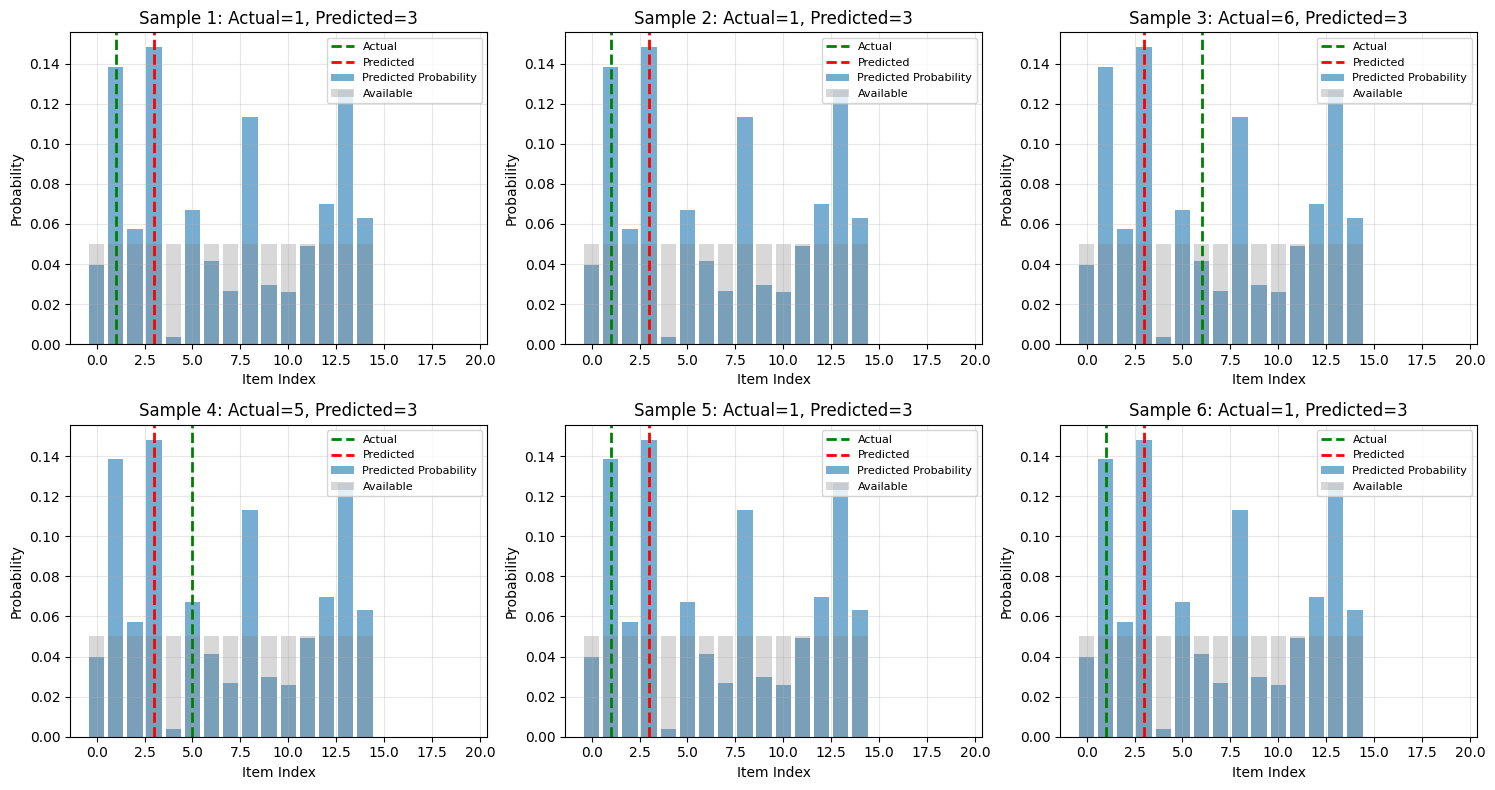

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    
    # Get availability and predictions for this sample
    availability = X_test_subset[i]
    probs = predictions[i]
    actual_choice = y_test_subset[i]
    predicted_choice = predicted_choices[i]
    
    # Plot
    items = np.arange(n_products)
    ax.bar(items, probs, alpha=0.6, label='Predicted Probability')
    ax.bar(items, availability * 0.05, alpha=0.3, label='Available', color='gray')
    ax.axvline(actual_choice, color='green', linestyle='--', linewidth=2, label='Actual')
    ax.axvline(predicted_choice, color='red', linestyle='--', linewidth=2, label='Predicted')
    
    ax.set_xlabel('Item Index')
    ax.set_ylabel('Probability')
    ax.set_title(f'Sample {i+1}: Actual={actual_choice}, Predicted={predicted_choice}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Model Summary

The **DeepHaloFeatureless** model successfully learns choice patterns from availability masks alone, without requiring any item or customer features.

### Key Features:
- ✅ Operates purely on binary availability masks
- ✅ Uses residual blocks (Quadratic and Exponential) for deep learning
- ✅ Integrates seamlessly with choice-learn's ChoiceModel API
- ✅ Supports standard optimizers (Adam, L-BFGS, etc.)
- ✅ Compatible with ChoiceDataset for easy data handling

### Usage:
```python
from choice_learn.models import DeepHaloFeatureless

model = DeepHaloFeatureless(
    opt_size=20,
    depth=5,
    resnet_width=64,
    block_types=['qua', 'qua', 'qua', 'qua'],
    optimizer='Adam',
    lr=0.001
)

model.fit(dataset)
predictions = model.predict_probas(dataset_test)
```

## 11. Bonus: Compare NLL vs MSE Loss

Let's train another model with MSE loss to see the difference in performance.

In [26]:
# Reload all related modules to get the latest changes
import importlib
import sys

# Remove cached modules
if 'choice_learn.models.deephalo_featureless' in sys.modules:
    del sys.modules['choice_learn.models.deephalo_featureless']
if 'choice_learn.models' in sys.modules:
    del sys.modules['choice_learn.models']

# Re-import
from choice_learn.models.deephalo_featureless import DeepHaloFeatureless

print("✅ Module reloaded successfully!")

✅ Module reloaded successfully!


In [27]:
# Train a model with MSE loss for comparison
print("Training model with MSE loss...")
model_mse = DeepHaloFeatureless(
    opt_size=n_products,
    depth=5,
    resnet_width=348,
    block_types=['qua']*(5-1),
    optimizer='Adam',
    lr=0.0001,
    epochs=500,
    batch_size=1024,
    loss_type='mse'  # 使用 MSE 损失
)

history_mse = model_mse.fit(dataset_train)
print(f"MSE Model - Final training loss: {history_mse['train_loss'][-1]:.4f}")

Training model with MSE loss...
⚠️  Warning: Using MSE loss for discrete choice model. NLL/Cross-Entropy is recommended for better performance.


Epoch 499 Train Loss 0.0435: 100%|██████████| 500/500 [03:35<00:00,  2.32it/s]

MSE Model - Final training loss: 0.0435


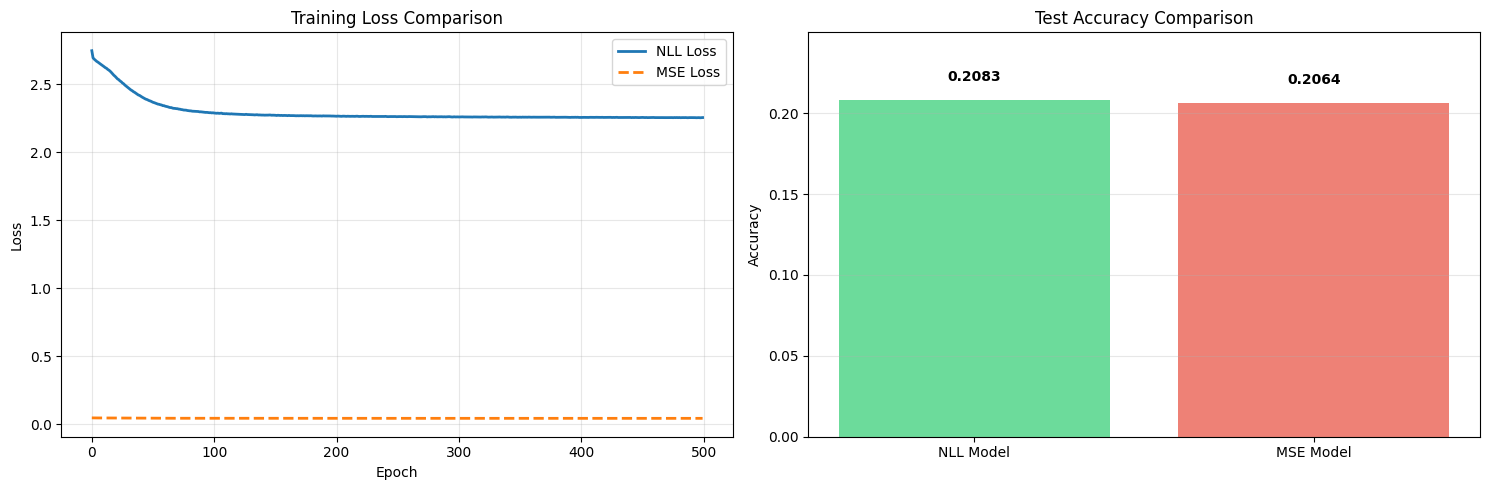


Performance Comparison:
NLL Model:
  - Test Accuracy: 0.2083
  - Test NLL: 2.4134

MSE Model:
  - Test Accuracy: 0.2064
  - Test NLL: 2.4117

Accuracy Difference: 0.0019


In [28]:
# Compare training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training loss comparison
ax1.plot(history['train_loss'], label='NLL Loss', linewidth=2)
ax1.plot(history_mse['train_loss'], label='MSE Loss', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Evaluate both models
test_nll_mse = model_mse.evaluate(dataset_test)
predictions_mse = model_mse.predict_probas(dataset_test)
predicted_choices_mse = np.argmax(predictions_mse, axis=1)
accuracy_mse = (predicted_choices_mse == y_test_subset).mean()

# Accuracy comparison
models = ['NLL Model', 'MSE Model']
accuracies = [accuracy, accuracy_mse]
colors = ['#2ecc71', '#e74c3c']

ax2.bar(models, accuracies, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy Comparison')
ax2.set_ylim([0, max(accuracies) * 1.2])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (model, acc) in enumerate(zip(models, accuracies)):
    ax2.text(i, acc + 0.01, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Performance Comparison:")
print("="*50)
print(f"NLL Model:")
print(f"  - Test Accuracy: {accuracy:.4f}")
print(f"  - Test NLL: {test_nll:.4f}")
print(f"\nMSE Model:")
print(f"  - Test Accuracy: {accuracy_mse:.4f}")
print(f"  - Test NLL: {test_nll_mse:.4f}")
print(f"\nAccuracy Difference: {(accuracy - accuracy_mse):.4f}")
print("="*50)

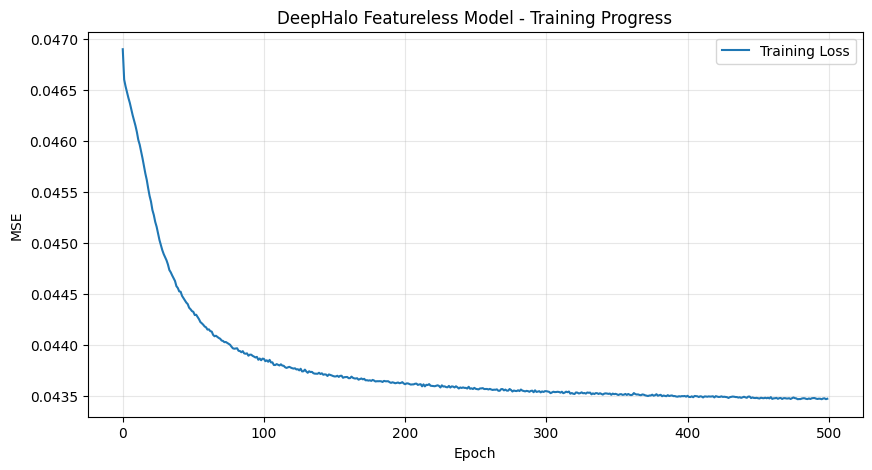

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(history_mse['train_loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('DeepHalo Featureless Model - Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Key Takeaways:

**NLL (Negative Log-Likelihood) Loss:**
- ✅ Theoretically correct for discrete choice problems
- ✅ Directly maximizes the probability of correct choices
- ✅ Better gradient properties for probability outputs
- ✅ Usually achieves better accuracy

**MSE (Mean Squared Error) Loss:**
- ⚠️ Not theoretically motivated for classification
- ⚠️ Treats all errors equally (no probabilistic interpretation)
- ⚠️ May converge slower or to suboptimal solutions
- ❌ Generally worse performance on discrete choice tasks

**Recommendation:** Use `loss_type='nll'` (default) for discrete choice modeling.